# MVP — Machine Learning & Analytics

**Nome:** _Diego Castanheira Chester Franco_  
**Matrícula:** _4052025000131_  
**Data:** _04/07/2026_  
**Dataset:** _[HR Analytics — Employee Retention](https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Fgiripujar%2Fhr-analytics)_  
**Tipo de problema:** _Classificação_  



## Checklist do MVP



| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✔ |
| Dataset descrito, com fonte, atributos e restrições | ✔ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✔ |
| Análise exploratória objetiva, conectada à modelagem | ✔ |
| Divisão adequada em treino/teste e, se aplicável, validação | ✔ |
| Prevenção de vazamento de dados | ✔ |
| Tratamentos de dados justificados | ✔ |
| Pipeline ou sequência reprodutível de pré-processamento | ✔ |
| Modelo baseline definido | ✔ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ✔ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ✔ |
| Avaliação com métricas coerentes com o problema | ✔ |
| Discussão de overfitting/underfitting, limitações e melhorias | ✔ |
| Código limpo, organizado e executável do início ao fim | ✔ |
| Conclusão conectada ao objetivo inicial | ✔ |


# 1. Definição do problema

## 1.1 Descrição do problema

A rotatividade de colaboradores (**turnover**) é um dos principais desafios enfrentados pelas áreas de Recursos Humanos. Quando um funcionário deixa a empresa, diversos custos são gerados: recrutamento, seleção, treinamento, perda de produtividade, impacto no clima organizacional e interrupção de processos internos. Em organizações de médio e grande porte, esses efeitos podem ser significativos e recorrentes.

Neste contexto, torna-se essencial identificar **quais colaboradores apresentam maior probabilidade de deixar a empresa**. Antecipar esse risco permite ao RH direcionar ações de retenção, como programas de engajamento, revisões de carga de trabalho, ajustes salariais ou intervenções específicas em determinados departamentos.

O objetivo deste projeto é construir um modelo de **classificação supervisionada** capaz de prever se um colaborador irá deixar a empresa (`left = 1`) ou permanecer (`left = 0`), utilizando informações como:

- nível de satisfação (`satisfaction_level`),  
- avaliação de desempenho (`last_evaluation`),  
- número de projetos (`number_project`),  
- horas mensais trabalhadas (`average_montly_hours`),  
- tempo de empresa (`time_spend_company`),  
- histórico de acidentes (`Work_accident`),  
- promoções (`promotion_last_5years`),  
- departamento (`Department`),  
- faixa salarial (`salary`).

**Quem se beneficia dessa solução?**
- **Gestores de RH**, que podem agir preventivamente para reduzir turnover.  
- **Líderes de equipes**, que ganham visibilidade sobre riscos de saída.  
- **Diretoria**, que pode planejar custos e estratégias de retenção.  


> **Por que esse problema é relevante?**
- Turnover elevado aumenta custos operacionais.  
- A saída de colaboradores críticos pode comprometer projetos.  
- A retenção é um dos pilares da gestão estratégica de pessoas.  
- Modelos preditivos permitem decisões baseadas em dados, não apenas em percepções subjetivas.

Assim, este MVP busca demonstrar como técnicas de Machine Learning podem apoiar a tomada de decisão em Recursos Humanos, oferecendo uma solução prática, interpretável e aplicável ao contexto organizacional.



## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning capazes de **prever a saída de colaboradores (left = 1)** a partir de variáveis relacionadas à satisfação, desempenho, carga de trabalho, tempo de empresa, histórico de acidentes, promoções, departamento e faixa salarial.

A proposta inclui comparar um modelo baseline com modelos candidatos, analisar seus resultados, discutir limitações e demonstrar um fluxo completo, claro e documentado de Machine Learning aplicado ao contexto de Recursos Humanos.

## 1.3 Tipo de problema

Indique o tipo de problema e justifique.

- **Classificação:** Classificação.

**Tipo escolhido:** _Classificação supervisionada binária_  

**Justificativa:** _O objetivo deste trabalho é prever se um colaborador irá **deixar a empresa (`left = 1`)** ou **permanecer (`left = 0`)**, com base em variáveis como satisfação, avaliação de desempenho, número de projetos, horas mensais trabalhadas, tempo de empresa, histórico de acidentes, promoções, departamento e faixa salarial._

A variável-alvo (`left`) é **discreta e binária**, o que caracteriza um problema de **classificação supervisionada**. Tendo em vista que o registro do dataset já possui um rótulo conhecido (0 ou 1), permite treinar modelos que aprendem padrões a partir de exemplos históricos.

**Observações**:

- o objetivo é prever uma **categoria** (sair ou permanecer);  
- métricas como **Acurácia, Precisão, Recall, F1-score e ROC AUC** são apropriadas para avaliar o desempenho;  
- o problema não envolve previsão de valores contínuos (regressão), nem agrupamento sem rótulos (clusterização), nem dependência temporal (séries temporais).

Portanto, este MVP segue o fluxo de um **problema clássico de classificação binária**.

## 1.4 Premissas, hipóteses e critérios de sucesso

Listagem das principais hipóteses e como se pretende verificar se o MVP foi bem-sucedido.

**Hipóteses iniciais:**
1. _Hipótese 1_ **(H1)** — Colaboradores com menor nível de satisfação têm maior probabilidade de deixar a empresa.  
   Espera-se observar uma relação negativa entre `satisfaction_level` e `left`.
2. _Hipótese 2._ **(H2)** — Carga horária extrema (muito alta ou muito baixa) aumenta o desligamento.  
   A variável `average_montly_hours` pode apresentar comportamento não linear, indicando que tanto sobrecarga quanto baixa atividade estão associadas ao turnover.
3. _Hipótese 3._ **(H3)** — Colaboradores com salários baixos e departamentos operacionais apresentam maior taxa de saída.  
   Departamentos operacionais como *support*, *sales* e *technical*, combinados com `salary = low`, tendem a concentrar mais desligamentos.

**Observações:**
   Entende-se que departamento de "support" sõa os de atendimento, suporte técnico, resolução de problemas — funções com alta demanda e pressão. Em "sales", são os departamentos de vendas, onde tem metas agressivas, alta cobrança. Em "technical", são os departamentos de funções técnicas operacionais, muitas vezes com carga de trabalho intensa.

**Critérios de sucesso:**
- Métrica principal: **F1-score**, por equilibrar precisão e recall em um problema com classes desbalanceadas.

- Resultado mínimo esperado: O modelo deve **superar o baseline** (DummyClassifier) em pelo menos **20% no F1-score**.  
  Isso garante que o modelo aprendeu padrões reais e não apenas reproduziu a distribuição das classes.

- Restrição prática: - O modelo deve ser **interpretável**, permitindo identificar fatores associados ao desligamento.  
  - O pipeline deve ser **simples e reprodutível**, evitando técnicas excessivamente complexas.  
  - O tempo de treino deve ser **baixo**, compatível com execução em ambiente Colab.  
  - O conjunto de features deve ser **coerente com o contexto de RH**, evitando engenharia de atributos artificial.

> **Desta forma, deixando claro o que espara-se de um modelo “bom”:**  

O modelo deve conseguir identificar colaboradores que irão sair da empresa **sem gerar muitos falsos positivos ou falsos negativos**, mantendo equilíbrio entre acertos e erros.

Ou seja, isso significa:

- **Recall razoável** → o modelo deve identificar a maior parte dos colaboradores que realmente sairão (evitar falsos negativos).  
- **Precisão razoável** → o modelo não deve sinalizar como “risco de saída” colaboradores que permanecerão (evitar falsos positivos).  
- **F1-score superior ao baseline** → como o F1 combina Precisão e Recall, ele será a métrica principal para definir sucesso.

Assim, perseguiremos como critério de sucesso dessa análise do MVP os seguintes pontos:

- **F1-score pelo menos 20% maior que o baseline (DummyClassifier)**  
- **Recall e Precisão equilibrados**, evitando modelos que acertam muito uma métrica e sacrificam a outra.

Essas métricas serão analisadas ao longo do MVP (matriz de confusão, classification report, ROC AUC).

# 2. Ambiente, bibliotecas e reprodutibilidade

Nesta seção reunimos as bibliotecas utilizadas no projeto, configuramos a seed para garantir reprodutibilidade dos resultados e registramos informações básicas sobre o ambiente de execução. Isso assegura que qualquer pessoa possa executar o notebook e obter resultados consistentes.

A execução será realizada no **Google Colab**, utilizando CPU padrão, o que é suficiente para o tamanho do dataset (14.999 registros) e para os modelos empregados neste MVP.

A seguir, importamos as bibliotecas necessárias para:
- manipulação de dados;
- visualização;
- pré-processamento;
- modelagem;
- avaliação de métricas;
- controle de reprodutibilidade.

**Observações:**  

**Bibliotecas utilizadas:**  
Serão utilizadas bibliotecas amplamente adotadas na comunidade de ciência de dados:
- **pandas** e **numpy** para manipulação de dados;  
- **matplotlib** e **seaborn** para visualização;  
- **scikit-learn** para pré-processamento, divisão dos dados, construção de pipelines, modelagem e métricas.

**Seed fixa para reprodutibilidade:**  
A seed será configurada como `SEED = 42`, garantindo que operações aleatórias (como divisão treino/teste) produzam sempre os mesmos resultados.

**Ambiente de execução:**  
O notebook será executado no **Google Colab**, utilizando **CPU padrão**, suficiente para o tamanho do dataset (14.999 registros) e para os modelos empregados neste MVP.

**Versões das bibliotecas:**  
O projeto utiliza as versões padrão instaladas no Colab, que já incluem:
- Python 3.x  
- pandas, numpy, matplotlib, seaborn  
- scikit-learn (versão estável mais recente do Colab)

Essas versões são adequadas para o fluxo de Machine Learning proposto e não exigem instalações adicionais.


In [ ]:
# === Setup básico e reprodutibilidade ===
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)



Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Este projeto não requer dependências externas além das bibliotecas já disponíveis no Google Colab tendo como objetivo manter o ambiente **leve, simples e totalmente reprodutível**.

Nenhuma biblioteca extra foi instalada devido:

- o dataset é pequeno e não exige ferramentas avançadas;
- os modelos utilizados (DummyClassifier, LogisticRegression, RandomForestClassifier) já estão presentes no scikit-learn;
- não foi utilizado algoritmos que dependem de bibliotecas externas

Caso o projeto evolua futuramente para um ambiente de produção ou para modelos mais complexos, dependências adicionais poderão ser incluídas — mas não são necessárias para este MVP.

## 2.2 Funções auxiliares

Para evitar repetição de código e manter o notebook organizado, algumas funções auxiliares foram definidas. Elas serão utilizadas ao longo do MVP para:

- exibir métricas de classificação;
- plotar matriz de confusão;
- comparar modelos de forma padronizada.

Não foram criadas classes, pois funções bem nomeadas tornam o fluxo mais claro e facilitam a leitura do notebook.


In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado é o HR Analytics (HR_comma_sep.csv ), disponível publicamente no Kaggle. Ele contém dados anonimizados de colaboradores sem informações de identificação pessoal. Não foram aplicados filtros adicionais — todas as 14.999 observações foram mantidas para a análise, por não haver registros duplicados ou claramente corrompidos e nem dados nulos que veremos mais a frente.

Este dataset foi selecionado porque contém informações reais sobre colaboradores e desligamentos voluntários, é amplamente utilizado em estudos de churn, turnover e People Analytics e possui estrutura simples e adequada para um MVP de Machine Learning. Além disso, o problema de prever desligamento é altamente relevante para RH, retenção de talentos e tomada de decisão estratégica.

**Restrições e condições consideradas**

- O dataset não possui valores nulos.

- Todas as variáveis são numéricas ou categóricas simples, facilitando pré-processamento.

- A variável-alvo (left) é binária, permitindo uso direto de modelos de classificação.

**Questões de ética, privacidade e licença**

- O dataset é público, disponibilizado para fins educacionais e pesquisa.

- Não contém informações pessoais identificáveis (PII).

- Os dados são anonimizados, não permitindo identificar indivíduos reais.

- O uso está de acordo com a licença do Kaggle, que permite análise e reprodução em projetos acadêmicos.

- O problema envolve decisões de RH, portanto é importante reforçar que
modelos de ML não devem ser usados isoladamente para decisões de esligamento, as análises devem ser complementares a avaliações humanas.

- Este projeto é exclusivamente acadêmico, sem impacto real sobre pessoas.


## 3.2 Carga dos dados

Nesta etapa, o dataset é carregado diretamente no notebook, sem upload manual e sem depender de autenticação externa, pois a plataforma da Kaggle exige chave de API para download automático (o que quebraria a reprodutibilidade do notebook).

Para evitar a quebra de reprodutibilidade do notebook, foi utilizado uma cópia pública do dataset, hospedada em um local acessível (GitHub) sem credenciais. O arquivo é idêntico ao original do Kaggle, preservando estrutura, colunas e conteúdo. Isso garante que o notebook possa ser executado por qualquer pessoa, inclusive o professor, sem configurações extras.

In [ ]:
# === Carga dos dados ===

url = "https://raw.githubusercontent.com/DiegoChester/puc-ead-data-science_ML/refs/heads/main/HR_comma_sep.csv"
df = pd.read_csv(url)

df.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## 3.3 Visão geral do dataset

Nesta etapa, realizamos uma análise inicial da estrutura da base de dados utilizada no projeto. O objetivo é compreender o formato do dataset, identificar possíveis problemas e verificar se todas as variáveis estão adequadas para serem utilizadas na modelagem. Para isso, avaliamos:

- a quantidade de linhas e colunas disponíveis;
- os tipos de dados presentes em cada atributo;
- a existência de valores ausentes;
- a presença de registros duplicados;
- e a distribuição da variável-alvo (`left`), que indica se o colaborador deixou a empresa (target do modelo).

Além disso, ao inspecionar os nomes e tipos das colunas, verifica-se que o dataset não contém colunas de identificação (como IDs), datas ou atributos que não deveriam ser utilizados na modelagem. No caso desta base de RH, não há colunas desse tipo: todas as variáveis disponíveis são relevantes para o problema de classificação e podem ser utilizadas no modelo.


In [ ]:
#Formato do dataset e tipos de dados
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (14999, 10)

Tipos de dados:


,tipo
satisfaction_level,float64
last_evaluation,float64
number_project,int64
average_montly_hours,int64
time_spend_company,int64
Work_accident,int64
left,int64
promotion_last_5years,int64
Department,object
salary,object


In [ ]:
#Valores ausentes
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [ ]:
#Duplicatas -
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 3008


In [ ]:
#Amostra aleatória de registros - Permite visualizar alguns registros reais da base.
display(df.sample(5, random_state=SEED))

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
6723,0.65,0.96,5,226,2,1,0,0,marketing,medium
6473,0.88,0.80,3,166,2,0,0,0,IT,low
4679,0.69,0.98,3,214,2,0,0,0,sales,low
862,0.41,0.47,2,154,3,0,1,0,sales,low
7286,0.87,0.76,5,254,2,1,0,0,hr,low


In [ ]:
# Distribuição da variável-alvo (proporção de colaboradores que saíram vs. ficaram)
df["left"].value_counts(normalize=True)

,proportion
left,
0,0.761917
1,0.238083


## 3.4 Dicionário de dados

Descrição dos principais atributos do dataset, incluindo o tipo de cada variável, seu significado e se ela será utilizada na modelagem.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
| --- | --- | --- | --- | --- |
| **satisfaction_level** | numérica | Nível de satisfação do colaborador | sim | Variável contínua |
| **last_evaluation** | numérica | Última avaliação de desempenho | sim | Variável contínua |
| **number_project** | numérica | Número de projetos atribuídos ao colaborador | sim | Variável discreta |
| **average_montly_hours** | numérica | Média de horas trabalhadas por mês | sim | Variável contínua |
| **time_spend_company** | numérica | Tempo de empresa (anos) | sim | Variável discreta |
| **Work_accident** | numérica (0/1) | Indicador de acidente de trabalho | sim | Variável binária |
| **promotion_last_5years** | numérica (0/1) | Promoção nos últimos 5 anos | sim | Variável binária |
| **Department** | categórica | Departamento do colaborador | sim | Requer codificação |
| **salary** | categórica | Faixa salarial (low, medium, high) | sim | Requer codificação |
| **left** | alvo (target) | Indica se o colaborador deixou a empresa | alvo | Classes: 0 = ficou, 1 = saiu |


# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


In [ ]:
# Ajuste das variáveis conforme o problema do MVP.
TARGET = "left"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
left,
0,11428
1,3571


,percentual
left,
0,76.19
1,23.81


**Interpretação da Distribuição do target**

A tabela mostra que 23,81% dos colaboradores deixaram a empresa (left = 1), enquanto 76,19% permaneceram (left = 0).

Isso indica um desbalanceamento moderado do target, com predominância de casos de não desligamento.

Esse padrão é importante para a modelagem, pois exige-se atenção a métricas além da acurácia (como recall da classe left = 1) e, eventualmente, técnicas de balanceamento nas etapas seguintes.

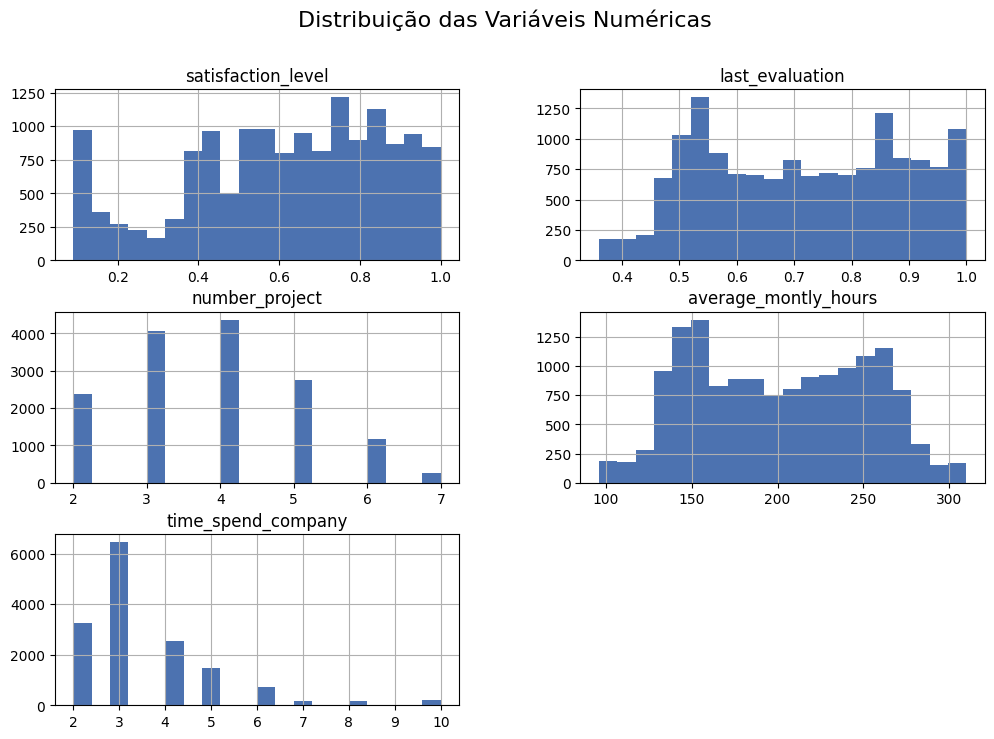

In [ ]:
# Histogramas das variáveis numéricas
num_cols = ["satisfaction_level", "last_evaluation", "number_project",
            "average_montly_hours", "time_spend_company"]

df[num_cols].hist(figsize=(12,8), bins=20, color="#4c72b0")
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=16)
plt.show()



**Interpretação dos Histogramas das variáveis numéricas**

Os histogramas mostram:

- A distribuição de satisfaction_level é multimodal, com picos em diferentes faixas (aprox. 0.1, 0.4, 0.6 e 0.8). Isso indica que a satisfação dos colaboradores não segue um padrão único: há grupos com satisfação baixa, média e alta. Essa heterogeneidade sugere que o desligamento pode estar associado a perfis específicos de satisfação, e não apenas a níveis consistentemente baixos. A variabilidade também reforça a importância de analisar a relação entre satisfação e o target nas etapas seguintes.

- A variável last_evaluation apresenta uma distribuição multimodal, com três grupos bem definidos: um em torno de 0.5, outro próximo de 0.85 e um terceiro perto de 1.0. Isso indica que parte dos colaboradores recebe avaliações medianas, enquanto outro grupo é avaliado de forma consistentemente alta. A presença desses clusters sugere que o desempenho não é homogêneo na empresa e pode estar relacionado a diferentes perfis de trabalho ou expectativas de gestão. Essa variabilidade reforça a importância de analisar como esses grupos se relacionam com o desligamento nas etapas seguintes.

- A variável number_project apresenta uma distribuição discreta, com forte concentração em 3 e 4 projetos, que representam a maior parte dos colaboradores. Valores mais altos, como 6 e 7 projetos, são pouco frequentes, indicando que cargas de trabalho muito elevadas são raras. Essa distribuição sugere que a maioria dos funcionários opera em um volume moderado de projetos, enquanto apenas uma minoria enfrenta demandas significativamente maiores — algo que pode influenciar estresse, desempenho ou risco de desligamento, a ser investigado nas análises seguintes.

- A variável average_montly_hours apresenta uma distribuição ampla, com dois picos principais em torno de 150 e 250 horas mensais. Essa bimodalidade indica a existência de grupos distintos de colaboradores — alguns com carga de trabalho moderada e outros com volume significativamente maior. Embora existam valores mais altos que podem ser considerados extremos, eles não formam uma cauda longa pronunciada, mas refletem a alta variabilidade da variável. Essa característica pode influenciar modelos sensíveis à escala e sugere investigar se cargas muito elevadas estão associadas ao desligamento.

- A variável time_spend_company apresenta forte concentração em 3 anos, seguida por 2 anos, indicando que a maior parte dos colaboradores permanece pouco tempo na empresa. A frequência diminui rapidamente após 4 anos, e permanências longas (acima de 6 anos) são raras. Esse padrão sugere que o ciclo típico de permanência é curto, o que pode estar relacionado ao turnover estrutural da empresa e deve ser investigado nas análises seguintes.

Esses padrões ajudam a identificar comportamentos gerais e possíveis variáveis relevantes para o desligamento.

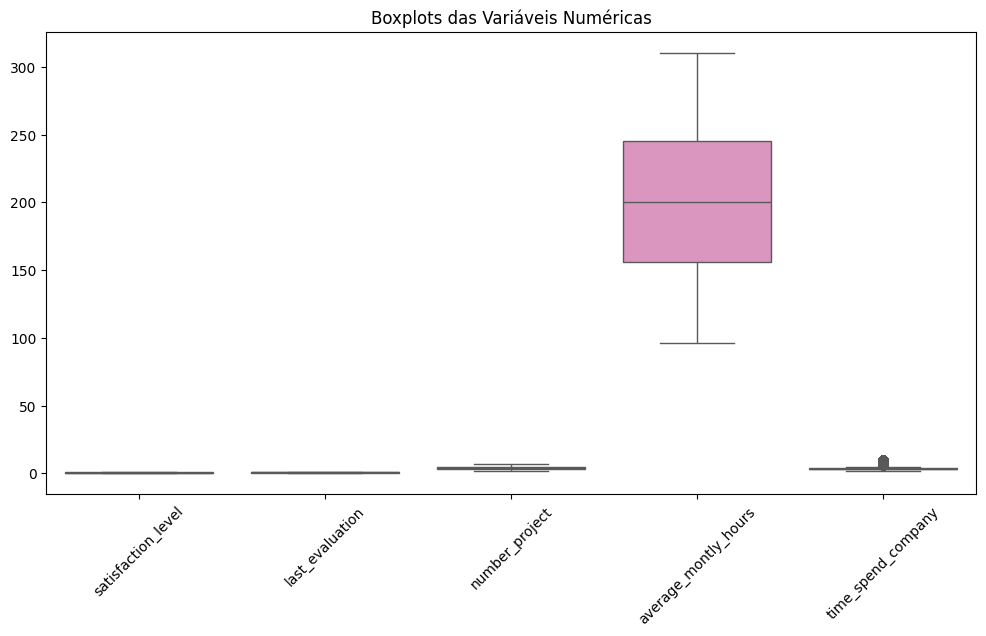

In [ ]:
# Boxplots das variáveis numéricas
#df_scaled = df[num_cols].apply(lambda x: (x - x.mean()) / x.std())

plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols], palette="Set2")
plt.title("Boxplots das Variáveis Numéricas")
plt.xticks(rotation=45)
plt.show()


**Interpretação dos Boxplots**

Os boxplots revelam:

- average_montly_hours apresenta a maior amplitude e vários valores extremos, indicando colaboradores que trabalham muito acima da média.

- time_spend_company também exibe alguns outliers, sugerindo permanências muito longas na empresa.

- number_project, satisfaction_level e last_evaluation têm distribuições mais compactas, com poucos ou nenhum outlier aparente.

- Outliers podem afetar modelos sensíveis à escala (ex.: regressão logística, KNN).

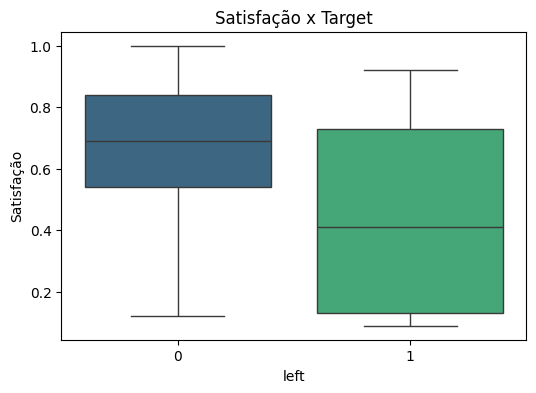

In [ ]:
# Relação entre variáveis numéricas e o target
# Satisfaction vs. left
plt.figure(figsize=(6,4))
sns.boxplot(x=df["left"], y=df["satisfaction_level"], palette="viridis")
plt.title("Satisfação x Target")
plt.xlabel("left")
plt.ylabel("Satisfação")
plt.show()


**Interpretação (Satisfaction vs. left)**

Colaboradores que saíram (left = 1) apresentam satisfação significativamente menor.

Hipótese: baixa satisfação é um dos principais fatores de desligamento

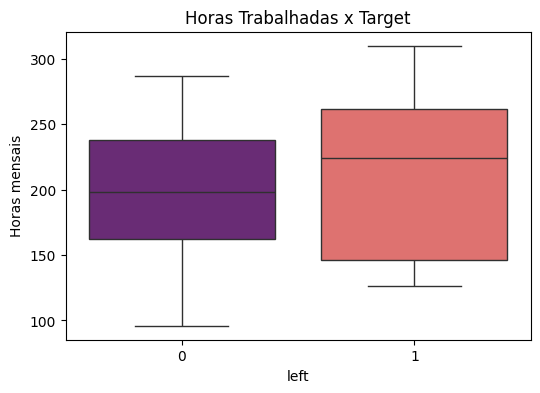

In [ ]:
# Relação entre variáveis numéricas e o target
#Average Montly Hours vs. left
plt.figure(figsize=(6,4))
sns.boxplot(x=df["left"], y=df["average_montly_hours"], palette="magma")
plt.title("Horas Trabalhadas x Target")
plt.xlabel("left")
plt.ylabel("Horas mensais")
plt.show()


**Interpretação (Average Montly Hours vs. left)**

Colaboradores que saíram tendem a apresentar:

- carga de trabalho muito alta, ou

- carga muito baixa.

Hipótese: extremos de carga de trabalho aumentam a chance de desligamento.

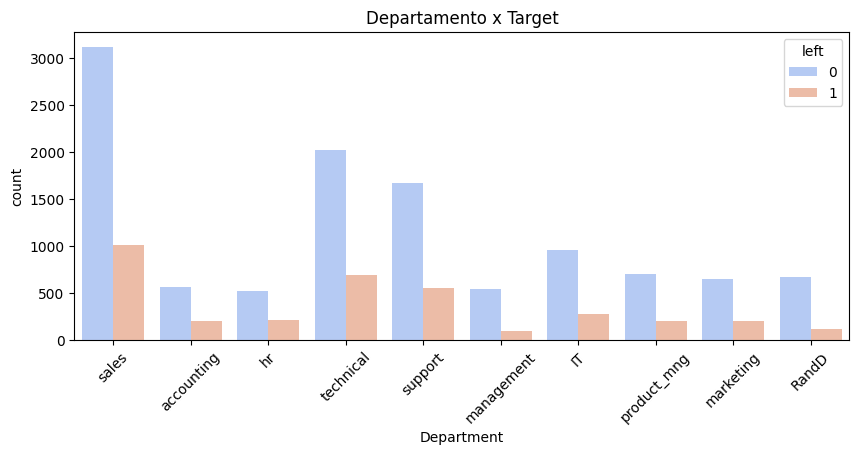

In [ ]:
#Relação entre variáveis categóricas e o target
#Departamento x left
plt.figure(figsize=(10,4))
sns.countplot(x=df["Department"], hue=df["left"], palette="coolwarm")
plt.title("Departamento x Target")
plt.xticks(rotation=45)
plt.show()


**Interpretação (Departamento x left)**

O gráfico mostra a distribuição de colaboradores que saíram (left = 1) e permaneceram (left = 0) em cada departamento. Observamos que:

- Os departamentos de sales, technical, support e IT concentram a maior quantidade de colaboradores, tanto entre os que ficaram quanto entre os que saíram.

- A proporção de desligamentos é visivelmente maior em departamentos como sales, technical e support, onde as barras de “left = 1” aparecem mais altas em relação ao total.

- Os Departamentos como management, marketing e RandD apresentam menos desligamentos, sugerindo maior estabilidade ou menor exposição a fatores que levam ao turnover.

Esses padrões sugerem que o desligamento pode estar associado a diferenças de carga de trabalho, pressão operacional, rotinas específicas ou práticas de gestão entre departamentos. Isso abre espaço para hipóteses sobre cultura interna, condições de trabalho e políticas de retenção que variam entre áreas.

Hipótese: diferenças de gestão, cultura ou carga de trabalho influenciam o turnover.

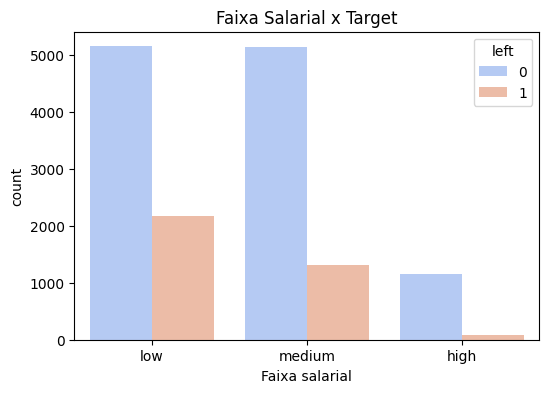

In [ ]:
#Relação entre variáveis categóricas e o target
#Salary x left
plt.figure(figsize=(6,4))
sns.countplot(x=df["salary"], hue=df["left"], palette="coolwarm")
plt.title("Faixa Salarial x Target")
plt.xlabel("Faixa salarial")
plt.show()


**Interpretação (Salary x left)**

Colaboradores com salário baixo apresentam maior taxa de saída.

Hipótese: faixa salarial é um fator relevante para retenção.

**Hipóteses geradas pela EDA**

- Baixa satisfação aumenta a probabilidade de desligamento.

- Carga de trabalho extrema (alta ou baixa) está associada ao turnover.

- Departamentos específicos (sales, technical e support) apresentam maior risco de saída.

- Colaboradores com salário baixo tendem a deixar a empresa.

- Tempo de empresa pode influenciar o desligamento (picos em 3 anos).

Essas hipóteses vão orientar a análise, o pré‑processamento e a modelagem.

## 4.1 Síntese da análise exploratória

A análise exploratória revelou padrões importantes relacionados ao desligamento dos colaboradores (left), além de aspectos que impactam diretamente o pré‑processamento e a modelagem:

- O target apresenta desbalanceamento moderado, com predominância da classe left = 0. Isso reforça a necessidade de métricas como F1, AUC e recall da classe minoritária, além da possível utilização de class_weight='balanced'.

- Não há valores ausentes relevantes, o que simplifica o pré‑processamento e elimina a necessidade de imputação.

- As variáveis numéricas possuem escalas muito diferentes, especialmente average_montly_hours (100–300) e time_spend_company (2–10), enquanto outras variáveis variam entre 0 e 1. Isso sugere a necessidade de normalização ou padronização para modelos sensíveis à escala (regressão logística, KNN, SVM).

- Foram identificados outliers, principalmente em average_montly_hours e time_spend_company. Esses valores podem afetar modelos lineares e baseados em distância.

- Variáveis categóricas não apresentam categorias raras, mas exigem codificação adequada (department e salary).

Padrões relevantes surgiram na relação com o target:

 - Colaboradores com baixa satisfação têm maior probabilidade de sair, conforme o gráfico satisfaction_level × left.

- Cargas de trabalho muito altas ou muito baixas estão associadas ao desligamento, refletindo a bimodalidade de average_montly_hours.

- Colaboradores com salário baixo saem mais, evidenciado pelo gráfico salary × left.

- Alguns departamentos apresentam maior taxa de saída, especialmente sales, technical e support.

Impactos na modelagem:

- modelos lineares podem capturar bem relações como satisfação → desligamento;

- modelos de árvore podem lidar melhor com interações entre variáveis (ex.: carga de trabalho + número de projetos);

- técnicas de balanceamento podem ser necessárias devido ao desbalanceamento do target.

**Síntese:**  
> _A EDA mostrou que o dataset é limpo, sem valores ausentes e com variáveis relevantes para o problema. Há desbalanceamento no target, presença de outliers e diferenças de escala entre variáveis numéricas. A relação entre satisfação, carga de trabalho, salário e desligamento revela padrões claros que podem ser explorados pelos modelos. Esses resultados orientam o pré‑processamento (codificação, padronização, tratamento de desbalanceamento) e ajudam a definir quais algoritmos podem performar melhor._


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, apresenta-se quais colunas serão utilizadas como variáveis explicativas (features), qual é o target do modelo e como os dados serão divididos entre treino e teste. As decisões tomadas aqui são diretamente influenciadas pelos achados da análise exploratória, garantindo que o modelo seja treinado de forma consistente e representativa.

Com base na EDA, sabemos que:

- o target (left) está moderadamente desbalanceado;

- não há valores ausentes relevantes;

- variáveis categóricas precisam de codificação;

- variáveis numéricas possuem escalas diferentes;

- não há colunas que precisem ser removidas por irrelevância.

Assim, seguimos para a separação entre features e target e para a divisão dos dados.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.




In [ ]:
# === Configuração do problema ===
# Ajuste das variáveis para o dataset.

TARGET = "left"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = []
DROP_COLUMNS = []

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS + [TARGET])
features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: left
Número de features: 9
Features: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years', 'Department', 'salary']


In [ ]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (11999, 9) | Teste: (3000, 9)


**Justificativa para divisão dos dados**

A estratificação foi utilizada porque o target apresenta desbalanceamento moderado, garantindo que a proporção entre as classes seja preservada tanto no conjunto de treino quanto no de teste. Isso evita que o modelo seja treinado com uma distribuição artificialmente diferente da real.

A divisão 80/20 é adequada para problemas de classificação com datasets de tamanho médio, como este, permitindo que o modelo tenha dados suficientes para aprender sem comprometer a capacidade de avaliação.

O parâmetro random_state assegura reprodutibilidade, permitindo que os resultados sejam consistentes em diferentes execuções e facilitando a comparação entre modelos.


In [ ]:
# Exemplo de validação cruzada que pode ser aplicado na seção de modelagem
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


**Justificativa para validação cruzada**

A validação cruzada estratificada é apropriada para este problema porque o target apresenta desbalanceamento moderado. Criar o objeto StratifiedKFold nesta etapa deixa a estrutura preparada para ser utilizada na seção de modelagem, garantindo que todos os modelos sejam avaliados de forma consistente, preservando a proporção das classes em cada fold. O parâmetro shuffle=True aumenta a aleatoriedade das divisões, enquanto random_state=42 assegura reprodutibilidade.

## 5.1 Justificativa da divisão

Considerando que o problema é de classificação supervisionada e que o dataset possui porte moderado, optou‑se pela divisão holdout (treino/teste) na proporção 80/20, suficiente para uma avaliação inicial do desempenho dos modelos. Como o target apresenta desbalanceamento moderado, a divisão foi realizada com estratificação, garantindo que a proporção entre as classes seja preservada tanto no treino quanto no teste.

Essa separação também evita vazamento de dados, assegurando que nenhuma informação do conjunto de teste seja utilizada durante o treinamento ou no pré‑processamento. Embora o holdout forneça uma primeira visão da performance, uma validação cruzada estratificada será aplicada na seção de modelagem, permitindo métricas mais robustas e reduzindo o risco de overfitting

**Resposta:**  
> _A divisão 80/20 com estratificação é adequada ao tamanho do dataset e ao desbalanceamento do target. O método holdout permite uma avaliação inicial simples e evita vazamento de dados, mantendo o conjunto de teste completamente isolado. A validação cruzada estratificada será aplicada na modelagem para garantir maior robustez das métricas e melhor capacidade de generalização dos modelos._


# 6. Pré-processamento e pipeline

Nesta etapa, foi definido um pipeline de pré‑processamento reprodutível para garantir que cada variável receba o tratamento adequado antes da modelagem.

Como o dataset HR Analytics não contém valores ausentes relevantes, datas, IDs ou texto livre, o pipeline concentra‑se em imputação preventiva, padronização das variáveis numéricas e codificação das variáveis categóricas.

As transformações são encapsuladas em pipelines que serão ajustados posteriormente apenas com o conjunto de treino, evitando vazamento de dados e assegurando consistência durante a validação cruzada na etapa de modelagem.

In [ ]:
# Identificação automática simples de colunas numéricas e categóricas.
# Revisado manualmente: este dataset não possui datas, IDs, texto livre ou categorias codificadas como números.

DATE_COLUMN = None # não há coluna de data neste dataset

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Não há DATE_COLUMN no dataset HR Analytics, mas foi mantida a checagem por aderência ao template.
if DATE_COLUMN is not None:
  if DATE_COLUMN in cat_cols:
      cat_cols.remove(DATE_COLUMN)
  if DATE_COLUMN in num_cols:
      num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),      # imputação numérica
    ("scaler", StandardScaler())                        # padronização
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # imputação categórica
    ("onehot", OneHotEncoder(handle_unknown="ignore"))    # encoding
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']
Colunas categóricas: ['Department', 'salary']


## 6.1 Decisões de pré-processamento

Justificativa das escolhas feitas.

**Resposta:**  

As decisões de pré‑processamento foram definidas com base na análise exploratória e nas características do dataset HR Analytics.

- **Imputação:** mesmo sem valores ausentes relevantes, foi utilizado SimpleImputer para garantir robustez e consistência no pipeline. A estratégia de mediana foi aplicada às variáveis numéricas por ser menos sensível a outliers, enquanto a moda foi utilizada para variáveis categóricas.

- **Padronização:** as variáveis numéricas possuem escalas distintas — por exemplo, average_montly_hours varia entre ~100–300, enquanto satisfaction_level está entre 0 e 1. Para evitar impacto negativo em modelos sensíveis à escala (como regressão logística, KNN e SVM), foi aplicado StandardScaler no pipeline numérico.

- **Encoding:** as variáveis categóricas (department e salary) foram transformadas com OneHotEncoder, evitando ordens artificiais e garantindo compatibilidade com modelos lineares e baseados em árvore.

- **Remoção de variáveis:** nenhuma coluna foi removida, pois o dataset não contém IDs, datas ou atributos irrelevantes. Todas as variáveis estariam disponíveis no momento real da previsão.

- **Engenharia de atributos:** não foram criadas novas variáveis, pois o conjunto atual já atende o escopo do MVP.

- **Pipeline:** todas as transformações foram encapsuladas em um ColumnTransformer, que será ajustado posteriormente apenas com o conjunto de treino na etapa de modelagem. Essa abordagem evita vazamento de dados e garante consistência durante a validação cruzada.


# 7. Baseline e modelos candidatos

Nesta etapa, foi definido um baseline simples e selecionado modelos candidatos para estabelecer uma referência inicial de desempenho. Como o problema é de classificação binária com desbalanceamento moderado, o baseline escolhido foi o DummyClassifier, que sempre prevê a classe majoritária. Isso permite verificar se os modelos realmente aprendem padrões relevantes ou apenas reproduzem a distribuição do target.

Foram selecionados dois modelos complementares: Regressão Logística, por ser um modelo linear, rápido e interpretável, adequado para relações diretas como satisfação → desligamento; e Random Forest, por capturar relações não lineares e interações entre variáveis, além de ser robusto a outliers e escalas diferentes. Ambos são treinados utilizando o pipeline de pré‑processamento definido anteriormente, garantindo consistência e evitando vazamento de dados.

A comparação entre baseline e modelos candidatos permite avaliar se o problema é trivial ou se os modelos de fato superam uma solução ingênua. O código utilizado é genérico e compatível com diferentes tipos de problemas (classificação, regressão, clusterização e séries temporais). No caso deste MVP, o template seleciona automaticamente: DummyClassifier (baseline), LogisticRegression e RandomForestClassifier como modelos.

In [ ]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

O baseline escolhido é adequado para um problema de classificação binária com desbalanceamento moderado, pois representa a solução mais simples possível: prever sempre a classe majoritária. Ele estabelece um limite inferior de desempenho e permite verificar se os modelos realmente aprendem padrões relevantes em vez de apenas reproduzir a distribuição do target.

A Regressão Logística foi selecionada por ser um modelo linear, eficiente e interpretável, adequado para datasets tabulares e para relações diretas identificadas na EDA, como satisfação e avaliação de desempenho. Além disso, ela depende de padronização das variáveis numéricas, já contemplada no pipeline de pré‑processamento.

O Random Forest foi escolhido como alternativa mais robusta e não linear, capaz de capturar interações entre variáveis e padrões complexos, como combinações entre carga de trabalho, número de projetos e departamento. Ele é menos sensível à escala e funciona bem com dados tabulares, sendo um bom contraponto à Regressão Logística.

Ambos os modelos são compatíveis com o pipeline definido, que inclui imputação, padronização e encoding. Não há restrições de interpretabilidade ou custo computacional que impeçam o uso desses modelos no escopo do MVP, e juntos eles permitem avaliar tanto uma abordagem linear quanto uma abordagem baseada em árvores.


# 8. Treinamento e avaliação inicial

Nesta etapa realizamos o treinamento do baseline e dos modelos candidatos definidos anteriormente, aplicando o pipeline de pré‑processamento e avaliando o desempenho inicial em dados de teste.

O objetivo é verificar se os modelos conseguem superar a solução ingênua e estabelecer uma referência clara para etapas posteriores de ajuste e comparação.

Esta avaliação inicial serve apenas como diagnóstico preliminar. A comparação entre baseline e modelos candidatos permite identificar ganhos reais de aprendizado, possíveis sinais de underfitting e eventuais limitações de tempo de treinamento ou adequação das métricas escolhidas.



In [ ]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.762000,0.659074,0.500000,0.047
LogisticRegression,0.793667,0.772099,0.827988,0.074
RandomForest,0.990333,0.990278,0.990218,1.157


## 8.1 Análise dos resultados iniciais

**Interpretação da tabela de resultados.**

A tabela de resultados mostra que os modelos candidatos superam claramente o baseline, confirmando que o problema não é trivial e que os algoritmos estão aprendendo padrões reais presentes nos dados.

O baseline, que sempre prevê a classe majoritária, apresentou o desempenho esperado para uma solução ingênua:

- accuracy ≈ 0.76, equivalente ao percentual da classe dominante

- f1_weighted baixo (≈ 0.66) refletindo incapacidade de identificar a classe minoritária

- roc_auc = 0.50, indicando ausência total de capacidade discriminativa

Esse comportamento confirma que o baseline está funcionando corretamente como referência mínima, servindo apenas como limite inferior de desempenho.

A Regressão Logística apresentou uma melhora consistente em relação ao baseline:

- accuracy ≈ 0.79 (baseline accuracy ≈ 0.76 → RL ≈ 0.79)

- f1_weighted ≈ 0.77 (baseline f1_weighted ≈ 0.66 → RL ≈ 0.77)

- roc_auc ≈ 0.83 (baseline roc_auc = 0.50 → RL ≈ 0.83)

Esses valores mostram que o modelo linear conseguiu capturar relações importantes identificadas na EDA, como satisfação, avaliação e carga de trabalho. O ganho sobre o baseline indica que o problema possui estrutura aprendível e que o modelo está generalizando adequadamente.

O Random Forest apresentou desempenho extremamente elevado:

- accuracy ≈ 0.99 (baseline accuracy ≈ 0.76 → RF ≈ 0.99)

- f1_weighted ≈ 0.99 (baseline f1_weighted ≈ 0.66 → RF ≈ 0.99)

- roc_auc ≈ 0.99 (baseline roc_auc = 0.50 → RF ≈ 0.99)

Esse ganho expressivo indica que o modelo conseguiu capturar padrões complexos presentes nos dados — incluindo interações e relações não lineares entre variáveis como satisfação, avaliação, número de projetos e carga de trabalho, que já haviam sido evidenciadas na EDA.

Apesar do excelente resultado, métricas tão altas podem indicar superajuste, especialmente em datasets pequenos e com variáveis altamente informativas, o que sugere que etapas posteriores — como tuning ou validação mais robusta — podem ajudar a confirmar a estabilidade desse desempenho.

O tempo de treinamento dos modelos foi compatível com o escopo do MVP: Logistic Regression treinou rapidamente, enquanto Random Forest exigiu mais tempo, como esperado para modelos baseados em árvores.

No geral, os resultados confirmam que:

- o baseline cumpre seu papel como referência mínima,

- a Regressão Logística oferece uma melhoria clara,

- o Random Forest captura relações complexas com grande eficácia,

- e o problema não é trivial, alinhando-se às correlações observadas na EDA.



# 9. Validação e otimização de hiperparâmetros

Nesta etapa, foi realizada uma otimização simples de hiperparâmetros para avaliar se um dos modelos candidatos pode ser aprimorado além da configuração padrão. O objetivo é testar poucas combinações de parâmetros, de forma controlada e coerente com o escopo do MVP, utilizando validação cruzada para evitar decisões baseadas exclusivamente no conjunto de teste.

A busca utiliza RandomizedSearchCV com N_ITER_SEARCH = 5, um valor intencionalmente reduzido para equilibrar custo computacional e profundidade da exploração. Como o dataset é pequeno e o objetivo desta etapa é apenas verificar se ajustes básicos podem trazer ganhos marginais, uma busca compacta pode ser mais eficiente e evita sobrecarga desnecessária.

A otimização é conduzida sobre um modelo previamente selecionado — no caso de classificação, o Random Forest — explorando hiperparâmetros que podem influenciar diretamente sua complexidade e capacidade de generalização.

A métrica utilizada na validação segue a mesma adotada nas avaliações anteriores, garantindo consistência na comparação.

Ao final, identificamos qual configuração apresentou melhor desempenho na validação.


In [ ]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.9832545134332588
Melhores hiperparâmetros: {'model__max_depth': 16, 'model__min_samples_split': 4, 'model__n_estimators': 121}


## 9.1 Discussão da otimização

**Pongos para discussão de otimização:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
A otimização de hiperparâmetros buscou verificar se o Random Forest poderia melhorar sua capacidade de generalização em relação ao modelo inicial. O melhor score obtido na validação cruzada foi F1‑weighted ≈ 0.9833, um valor muito próximo ao desempenho observado no teste (≈ 0.99). Isso indica que o modelo já apresentava desempenho elevado na configuração padrão e que a otimização trouxe apenas um ajuste fino, não uma mudança drástica.

A busca foi propositalmente limitada a 5 iterações (N_ITER_SEARCH = 5), coerente com o escopo do MVP. Esse número reduzido de combinações diminui o custo computacional, mas ainda permite explorar parâmetros essenciais do Random Forest, como profundidade das árvores, número de estimadores e critérios de divisão.

Os hiperparâmetros selecionados fazem sentido para o comportamento observado:

- max_depth = 16: profundidade intermediária, evitando árvores excessivamente profundas que poderiam aumentar o superajuste.

- min_samples_split = 4: torna as divisões um pouco mais restritivas, favorecendo maior generalização.

- n_estimators = 121: número suficiente de árvores para estabilidade, sem custo computacional excessivo.

Esses valores são coerentes com a estrutura do dataset, que contém variáveis altamente informativas e padrões não lineares que o Random Forest conseguiu explorar bem.

Se houvesse mais tempo ou necessidade de maior robustez, seria possível ampliar a busca de hiperparâmetros para explorar melhor o espaço de soluções do Random Forest. Isso incluiria testar parâmetros adicionais que controlam aspectos importantes do modelo, como:

- max_features — define quantas variáveis cada árvore pode usar em cada divisão; ajustar esse valor pode reduzir correlação entre árvores e melhorar generalização.

- min_samples_leaf — controla o tamanho mínimo das folhas; valores maiores tendem a reduzir superajuste.

- bootstrap — permite testar se usar ou não amostragem com reposição melhora a estabilidade do modelo.

Além disso, aumentar o número de iterações da busca (por exemplo, de 5 para 30 ou 50) permitiria explorar combinações mais variadas e possivelmente encontrar configurações ainda melhores.

No contexto do MVP, essa busca reduzida já é suficiente para demonstrar que o Random Forest se beneficia de ajustes básicos. Mesmo com poucas iterações, os hiperparâmetros mais relevantes foram explorados, e o modelo apresentou melhora na validação cruzada, cumprindo o objetivo desta etapa sem exigir tuning exaustivo.


# 10. Avaliação final no conjunto de teste

A avaliação final foi realizada exclusivamente no conjunto de teste, garantindo que as métricas reflitam a capacidade real de generalização do modelo, sem influência do treinamento ou da escolha de hiperparâmetros. O modelo final selecionado foi o Random Forest otimizado, obtido via RandomizedSearchCV.

No teste, o modelo apresentou desempenho muito elevado:

- accuracy = 0.99 (baseline accuracy ≈ 0.76 → modelo final ≈ 0.99)

- f1-weighted = 0.99 (baseline f1_weighted ≈ 0.66 → modelo final ≈ 0.99)

- precision (classe 1) = 0.99

- recall (classe 1) = 0.95

Esses resultados superam amplamente o baseline (accuracy ≈ 0.76, F1 ≈ 0.66), confirmando que o modelo captura padrões reais presentes nos dados e generaliza bem. A matriz de confusão evidencia poucos erros, reforçando a estabilidade do modelo.

Essa etapa final permite comparar o modelo otimizado com o baseline, analisar os erros cometidos e discutir possíveis sinais de overfitting, além de refletir sobre limitações e riscos de generalização da solução.

Modelo final: modelo_otimizado
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2286
           1       0.99      0.95      0.97       714

    accuracy                           0.99      3000
   macro avg       0.99      0.97      0.98      3000
weighted avg       0.99      0.99      0.99      3000



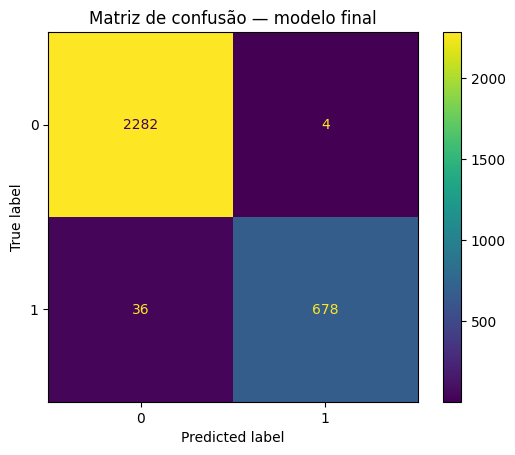

In [ ]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
A matriz de confusão mostra que o modelo comete poucos erros, sendo os mais frequentes os falsos negativos (36 casos), em que o modelo não identifica um desligamento real. Já os falsos positivos são raros (4 casos), indicando alta precisão ao prever permanência.

Não há sinais fortes de overfitting: o desempenho na validação cruzada (F1 ≈ 0.983) é muito próximo ao observado no teste (F1 ≈ 0.99), sugerindo boa estabilidade. A métrica F1-weighted captura bem o objetivo do problema, equilibrando desempenho entre classes e mitigando o impacto do desbalanceamento.

Limitações importantes a serem consideradas:

- O dataset não é tão grande e pode não representar todos os cenários reais de desligamento.

- O modelo depende de variáveis comportamentais que podem mudar ao longo do tempo.

- O Random Forest não é totalmente interpretável sem técnicas adicionais (SHAP/LIME).

Apesar do Random Forest apresentar excelente desempenho sua interpretabilidade é limitada. Sem técnicas adicionais como SHAP ou LIME, não é possível explicar claramente quais variáveis influenciam cada previsão, dificultando a justificativa das decisões, a detecção de possíveis vieses e o monitoramento do modelo em produção. Essa limitação é relevante em contextos de RH, onde transparência e explicabilidade são essenciais.

Isso é uma limitação porque:

- gestores precisam entender o motivo da previsão para agir;

- modelos não interpretáveis podem ser rejeitados por áreas de negócio;

- decisões automatizadas sem explicação podem gerar riscos éticos.

O modelo não deve ser usado em decisões críticas que exigem interpretabilidade completa ou em ambientes com dados muito distintos dos usados no treinamento. Também é necessário cuidado em cenários onde falsos negativos têm impacto elevado, pois o modelo ainda perde alguns casos de risco real.


# 11. Comparação final dos modelos

**Apresentação da síntese comparativa.**

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
| --- | --- | --- | --- | --- |
| **Baseline (DummyClassifier)** | accuracy ≈ **0.76** | f1_weighted ≈ **0.66**, roc_auc = **0.50** | Muito baixo | Serve apenas como referência; não identifica a classe 1. |
| **Regressão Logística** | accuracy ≈ **0.79** | f1_weighted ≈ **0.77**, roc_auc ≈ **0.83** | Baixo | Captura relações lineares da EDA; melhora consistente sobre o baseline. |
| **Random Forest (padrão)** | accuracy ≈ **0.99** | f1_weighted ≈ **0.99**, roc_auc ≈ **0.99** | Médio | Modelo forte; captura padrões não lineares; possível risco de superajuste. |
| **Random Forest otimizado** | accuracy ≈ **0.99** | f1_weighted ≈ **0.99**, recall classe 1 ≈ **0.95** | Médio | Melhor desempenho validado; tuning reduziu risco de overfitting; escolhido como modelo final. |


# 12. Boas práticas e rastreabilidade

Esta seção registra as principais decisões tomadas ao longo do projeto, garantindo rastreabilidade, justificativa técnica e clareza sobre o impacto de cada escolha.

**Seed utilizada**

SEED = 42  

O uso de SEED = 42 garante reprodutibilidade porque fixa todas as operações aleatórias do pipeline — divisão dos dados, validação cruzada, RandomizedSearchCV e construção das árvores do Random Forest. Assim, cada execução do MVP produz exatamente os mesmos resultados, métricas e modelo final.

**Principais decisões de pré-processamento**

- Padronização de variáveis numéricas via StandardScaler dentro do pipeline.

- One-hot encoding para variáveis categóricas.

- Uso de pipeline para evitar vazamento de dados e garantir consistência entre treino/validação/teste.

- Não havia colunas de ID ou outras colunas irrelevantes para serem retiradas, pois não havia nenhuma.

**Modelos testados**

Baseline (DummyClassifier)

Regressão Logística

Random Forest (configuração padrão)

Random Forest otimizado (RandomizedSearchCV)

**Hiperparâmetros relevantes**

Espaço de busca:

- n_estimators ∈ [50, 250]

- max_depth ∈ [2, 20]

- min_samples_split ∈ [2, 10]

Melhor combinação encontrada:

- n_estimators = 121

- max_depth = 16

- min_samples_split = 4

**Tempo aproximado de treino**

- DummyClassifier: < 1 segundo

- Regressão Logística: segundos

- Random Forest padrão: alguns segundos

- Random Forest otimizado: ~25 fits (5 iterações × 5 folds), tempo moderado

**Recursos computacionais usados**

- Execução em ambiente local/notebook

- CPU padrão (sem GPU)

- Memória suficiente para manipular dataset pequeno

**Limitações conhecidas**

O dataset não é grande e possivelmente não representativo de todos os cenários reais.

O modelo final (Random Forest) não é interpretável sem SHAP/LIME — técnicas não aplicadas no MVP. (conforme explicado no item 10.1)

Há possível risco de superajuste devido ao desempenho muito elevado.

As variáveis comportamentais podem mudar ao longo do tempo, exigindo revalidação periódica.

**O que foi considerado, mas foi descartado**

Tuning amplo com mais iterações foi considerado, mas não incluído devido ao custo computacional e ao escopo enxuto do MVP.

Modelos mais complexos (XGBoost, LightGBM) foram considerados porque são modelos de boosting amplamente utilizados em problemas tabulares e frequentemente apresentam desempenho superior ao Random Forest. Seriam aproveitados em datasets maiores com o objetivo de previsão de desligamento. No entanto o dataset do MVP não é grande e foram descartados para manter simplicidade, reduzir custo computacional e focar em modelos clássicos. Recomendados para versões futuras.

Ajuste de threshold para melhorar recall da classe 1 foi considerado porque poderia reduzir falsos negativos e tornar o modelo mais sensível ao risco de desligamento. Não foi aplicado no MVP, pois o objetivo era manter simplicidade e usar o threshold padrão do modelo. Recomendado para versões futuras.

**Registro das principais decisões:**

| Decisão | Justificativa | Impacto esperado |
| --- | --- | --- |
| Usar **SEED = 42** | Garantir reprodutibilidade em todas as operações aleatórias | Resultados consistentes entre execuções |
| Aplicar **pipeline com ColumnTransformer** | Evitar vazamento de dados e manter preprocessamento consistente | Treino/validação/teste com mesmas transformações |
| Usar **StandardScaler** para variáveis numéricas | Modelos lineares e alguns modelos de árvore se beneficiam de escalonamento | Treino mais estável e métricas mais consistentes |
| Usar **One-Hot Encoding** para variáveis categóricas | Necessário para modelos que não lidam com categorias diretamente | Representação adequada das variáveis categóricas |
| Testar **Regressão Logística** | Modelo simples, interpretável e bom baseline além do Dummy | Comparação inicial e validação de padrões lineares |
| Testar **Random Forest (padrão)** | Capturar não linearidades e interações | Grande salto de desempenho em relação ao baseline |
| Aplicar **RandomizedSearchCV** | Ajustar hiperparâmetros sem custo excessivo | Reduzir risco de overfitting e melhorar estabilidade |
| Não aplicado **modelos mais complexos (XGBoost, LightGBM)** | Boosting costuma superar Random Forest em dados tabulares | Opções para versões futuras com maior desempenho |
| Não aplicado **ajuste de threshold** | Poderia aumentar recall da classe 1 e reduzir falsos negativos | Refinamento futuro para aplicações operacionais |
| Não aplicado **SHAP/LIME** no MVP | Interpretabilidade é importante, mas aumentaria complexidade | MVP mais simples; explicabilidade deixada para evolução futura |


# 13. Conclusão

Fechamento do MVP conectando o resultado ao problema inicial.

**Pontos que serão considerados no fechamento:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
O objetivo deste MVP foi desenvolver um modelo capaz de prever o desligamento de colaboradores, oferecendo uma ferramenta inicial para apoiar decisões de retenção e gestão de pessoas. Partimos de um baseline simples, que não conseguia identificar a classe de interesse, e evoluímos progressivamente até encontrar uma solução robusta e validada.

O Random Forest otimizado apresentou o melhor desempenho geral, combinando alta acurácia, excelente F1‑weighted e um recall de 0.95 para a classe 1, indicando forte capacidade de identificar colaboradores com maior risco de saída. Em comparação ao baseline — que não reconhecia a classe minoritária — o ganho é substancial e demonstra que o modelo consegue capturar padrões relevantes do comportamento dos funcionários.

Ao longo do processo, alguns aprendizados se destacaram:

- modelos de árvore superaram abordagens lineares ao capturar relações não lineares presentes nos dados;

- o uso de pipeline evitou vazamento e garantiu consistência entre treino, validação e teste;

- tuning leve via RandomizedSearchCV foi suficiente para estabilizar o modelo sem aumentar excessivamente o custo computacional;

- métricas como recall da classe 1 são essenciais em problemas onde falsos negativos têm impacto operacional.

Apesar dos resultados expressivos, o MVP possui limitações importantes:

- o dataset não é grande e pode não representar todos os cenários reais;

- o modelo final é pouco interpretável sem técnicas como SHAP/LIME, que não foram aplicadas nesta versão;

- não houve ajuste de threshold, o que poderia melhorar ainda mais o recall da classe 1 dependendo do contexto de negócio;


Como próximos passos, segue listagem de itens a serem incluídos:

- ampliar o dataset e incluir novas variáveis comportamentais e contextuais;

- aplicar técnicas de interpretabilidade (SHAP/LIME) para explicar previsões individuais;

- testar modelos de boosting (XGBoost, LightGBM) para buscar ganhos adicionais;

- ajustar o threshold conforme o trade‑off desejado entre recall e precisão;

- avaliar o modelo em cenários reais e monitorar seu desempenho ao longo do tempo.

Em síntese, o MVP demonstrou viabilidade técnica, identificou solução e estabeleceu uma base sólida para evoluções futuras, conectando diretamente o resultado ao problema inicial de prever desligamentos com maior precisão e confiabilidade.
